# 📈 Cálculo II

`Matemática/Ciências` · **Engenharia da Computação** · `Python 3`

> **Técnicas de integração, impróprias, séries, potências e Taylor.**

Continuação do Cálculo: técnicas de integração avançadas, integrais impróprias, convergência de séries e aproximação por polinômios de Taylor.



## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 TÉCNICAS DE INTEGRAÇÃO

**Ideia:** Escolher a transformação que torna a integral mais simples.

- Substituição: u = g(x), du = g'(x) dx
- Por partes: ∫u dv = u·v − ∫v du
- Frações parciais: decomponha P(x)/Q(x), com grau P menor que grau Q
- Potências trig.: use 1 − sen²x = cos²x e 1 + tg²x = sec²x
- Subst. trig.: √(a²−x²) → x=a·sen θ; √(x²+a²) → x=a·tg θ

> 💡 **Dica:** Procure uma função interna acompanhada de sua derivada. Em integração por partes, use LIATE para escolher u.

### 🟢 APLICAÇÕES & IMPRÓPRIAS

**Ideia:** Integrais calculam medidas; limites tratam infinito e singularidades.

- Área: A = ∫[a,b] |f(x) − g(x)| dx
- Discos/anéis: V = π∫[a,b] [R² − r²] dx
- Cascas: V = 2π∫[a,b] (raio)(altura) dx
- Comprimento: L = ∫[a,b] √(1 + [f'(x)]²) dx
- Intervalo infinito: ∫[a,∞) f = lim b→∞ ∫[a,b] f
- p-teste: ∫[1,∞) 1/xᵖ dx converge somente quando p > 1

> 💡 **Dica:** Separe a integral em cada ponto de descontinuidade e avalie todos os limites. Uma única parte divergente faz o total divergir.

### 🟢 SEQUÊNCIAS & SÉRIES

**Ideia:** Convergência: termos ou somas parciais se aproximam de um valor.

- Sequência: aₙ → L quando n → ∞
- Série: ∑aₙ converge quando Sₙ = a₁ + ··· + aₙ possui limite finito
- Teste do termo: se aₙ não tende a 0, então ∑aₙ diverge
- Geométrica: ∑a·rⁿ = a/(1−r), para |r| < 1
- p-série: ∑1/nᵖ converge somente quando p > 1
- Testes: comparação, comparação-limite, razão, raiz e alternada

> 💡 **Dica:** aₙ → 0 é necessário, mas não suficiente. A série harmônica ∑1/n é o contraexemplo clássico.

### 🟢 POTÊNCIAS & TAYLOR

**Ideia:** Representar funções por polinômios infinitos perto de um centro a.

- Série de potências: ∑cₙ(x−a)ⁿ converge para |x−a| < R
- Intervalo: ache R pela razão/raiz e teste as extremidades separadamente
- Taylor: f(x) = Σ [f⁽ⁿ⁾(a)/n!] (x−a)ⁿ
- Maclaurin: Taylor com centro a = 0
- Modelos: eˣ = Σxⁿ/n!; 1/(1−x) = Σxⁿ, |x| < 1
- Trig.: sen x = Σ(−1)ⁿx²ⁿ⁺¹/(2n+1)!; cos x = Σ(−1)ⁿx²ⁿ/(2n)!

> 💡 **Dica:** O raio de convergência não decide as extremidades. Substitua cada extremo na série e aplique um teste novamente.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Calculo_II.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFont(TTFont('DVMono', str(FONT_DIR / 'DejaVuSansMono.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'TÉCNICAS DE<br/>INTEGRAÇÃO',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'tecnicas',
        'idea': 'Escolher a transformação que torna a integral mais simples.',
        'formulas': [
            '<b>Substituição:</b> u = g(x), du = g\'(x) dx',
            '<b>Por partes:</b> ∫u dv = u·v − ∫v du',
            '<b>Frações parciais:</b> decomponha P(x)/Q(x), com grau P menor que grau Q',
            '<b>Potências trig.:</b> use 1 − sen²x = cos²x e 1 + tg²x = sec²x',
            '<b>Subst. trig.:</b> √(a²−x²) → x=a·sen θ; √(x²+a²) → x=a·tg θ',
        ],
        'tip': 'Procure uma função interna acompanhada de sua derivada. Em integração por partes, use LIATE para escolher u.',
    },
    {
        'title': 'APLICAÇÕES &amp;<br/>IMPRÓPRIAS',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'improprias',
        'idea': 'Integrais calculam medidas; limites tratam infinito e singularidades.',
        'formulas': [
            '<b>Área:</b> A = ∫[a,b] |f(x) − g(x)| dx',
            '<b>Discos/anéis:</b> V = π∫[a,b] [R² − r²] dx',
            '<b>Cascas:</b> V = 2π∫[a,b] (raio)(altura) dx',
            '<b>Comprimento:</b> L = ∫[a,b] √(1 + [f\'(x)]²) dx',
            '<b>Intervalo infinito:</b> ∫[a,∞) f = lim b→∞ ∫[a,b] f',
            '<b>p-teste:</b> ∫[1,∞) 1/xᵖ dx converge somente quando p &gt; 1',
        ],
        'tip': 'Separe a integral em cada ponto de descontinuidade e avalie todos os limites. Uma única parte divergente faz o total divergir.',
    },
    {
        'title': 'SEQUÊNCIAS &amp;<br/>SÉRIES',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'series',
        'idea': 'Convergência: termos ou somas parciais se aproximam de um valor.',
        'formulas': [
            '<b>Sequência:</b> aₙ → L quando n → ∞',
            '<b>Série:</b> ∑aₙ converge quando Sₙ = a₁ + ··· + aₙ possui limite finito',
            '<b>Teste do termo:</b> se aₙ não tende a 0, então ∑aₙ diverge',
            '<b>Geométrica:</b> ∑a·rⁿ = a/(1−r), para |r| &lt; 1',
            '<b>p-série:</b> ∑1/nᵖ converge somente quando p &gt; 1',
            '<b>Testes:</b> comparação, comparação-limite, razão, raiz e alternada',
        ],
        'tip': 'aₙ → 0 é necessário, mas não suficiente. A série harmônica ∑1/n é o contraexemplo clássico.',
    },
    {
        'title': 'POTÊNCIAS &amp;<br/>TAYLOR',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'taylor',
        'idea': 'Representar funções por polinômios infinitos perto de um centro a.',
        'formulas': [
            '<b>Série de potências:</b> ∑cₙ(x−a)ⁿ converge para |x−a| &lt; R',
            '<b>Intervalo:</b> ache R pela razão/raiz e teste as extremidades separadamente',
            '<b>Taylor:</b> f(x) = Σ [f⁽ⁿ⁾(a)/n!] (x−a)ⁿ',
            '<b>Maclaurin:</b> Taylor com centro a = 0',
            '<b>Modelos:</b> eˣ = Σxⁿ/n!; 1/(1−x) = Σxⁿ, |x| &lt; 1',
            '<b>Trig.:</b> sen x = Σ(−1)ⁿx²ⁿ⁺¹/(2n+1)!; cos x = Σ(−1)ⁿx²ⁿ/(2n)!',
        ],
        'tip': 'O raio de convergência não decide as extremidades. Substitua cada extremo na série e aplique um teste novamente.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def axis(c, ox, oy, dw, dh):
    ax_y = oy + dh * 0.12
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, ax_y, ox + dw, ax_y)
    c.line(ox + dw * 0.03, oy, ox + dw * 0.03, oy + dh)
    return ax_y


def arrow(c, x1, y1, x2, y2, color, width=1.2):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    ah = 5
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + ah * math.cos(ang + delta), y2 + ah * math.sin(ang + delta))


def diagram_tecnicas(c, ox, oy, dw, dh, color):
    # Visual da substituição: expressão complexa -> variável auxiliar -> integral simples.
    y = oy + dh * 0.53
    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    left_w = dw * 0.42
    right_w = dw * 0.30
    c.roundRect(ox + 2, y - 17, left_w, 36, 5, fill=1, stroke=1)
    c.roundRect(ox + dw - right_w - 2, y - 17, right_w, 36, 5, fill=1, stroke=1)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 11.0)
    c.drawCentredString(ox + 2 + left_w / 2, y + 3, "f(g(x))·g'(x)")
    c.drawCentredString(ox + dw - right_w / 2 - 2, y + 3, 'f(u) du')
    arrow(c, ox + left_w + 8, y + 1, ox + dw - right_w - 10, y + 1, color, 1.3)
    c.setFont('DVCond', 9.6)
    c.setFillColor(MUTED)
    c.drawCentredString(ox + dw / 2, y + 16, 'u = g(x)')

    # Pequena curva abaixo para manter o vocabulário visual do modelo original.
    ax_y = oy + 5
    c.setStrokeColor(AXIS)
    c.line(ox + 2, ax_y, ox + dw - 2, ax_y)
    p = c.beginPath()
    p.moveTo(ox + dw * 0.05, ax_y + dh * 0.07)
    p.curveTo(
        ox + dw * 0.28,
        ax_y + dh * 0.06,
        ox + dw * 0.42,
        ax_y + dh * 0.30,
        ox + dw * 0.58,
        ax_y + dh * 0.26,
    )
    p.curveTo(
        ox + dw * 0.70,
        ax_y + dh * 0.23,
        ox + dw * 0.78,
        ax_y + dh * 0.40,
        ox + dw * 0.94,
        ax_y + dh * 0.48,
    )
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.drawPath(p, stroke=1, fill=0)


def diagram_improprias(c, ox, oy, dw, dh, color):
    ax_y = axis(c, ox, oy, dw, dh)
    n = 50
    pts = []
    for i in range(n + 1):
        t = i / n
        x = ox + dw * (0.06 + 0.88 * t)
        y = ax_y + dh * (0.72 * math.exp(-2.5 * t) + 0.04)
        pts.append((x, y))

    # Tail shading to infinity.
    lo = int(n * 0.48)
    shade = pts[lo:]
    sp = c.beginPath()
    sp.moveTo(shade[0][0], ax_y)
    for x, y in shade:
        sp.lineTo(x, y)
    sp.lineTo(shade[-1][0], ax_y)
    sp.close()
    c.setFillColor(color)
    c.setFillAlpha(0.20)
    c.drawPath(sp, stroke=0, fill=1)
    c.setFillAlpha(1)

    p = c.beginPath()
    p.moveTo(*pts[0])
    for point in pts[1:]:
        p.lineTo(*point)
    c.setStrokeColor(color)
    c.setLineWidth(1.6)
    c.drawPath(p, stroke=1, fill=0)

    c.setDash([2, 2])
    c.setLineWidth(0.9)
    c.line(shade[0][0], ax_y, shade[0][0], shade[0][1])
    c.setDash([])
    arrow(c, ox + dw * 0.72, ax_y + dh * 0.14, ox + dw * 0.94, ax_y + dh * 0.14, color, 1.0)
    c.setFillColor(MUTED)
    c.setFont('DVCond', 9.5)
    c.drawRightString(ox + dw * 0.96, ax_y + dh * 0.19, '∞')


def diagram_series(c, ox, oy, dw, dh, color):
    ax_y = axis(c, ox, oy, dw, dh)
    limit_y = ax_y + dh * 0.58
    c.setDash([3, 2])
    c.setStrokeColor(color)
    c.setLineWidth(1.0)
    c.line(ox + dw * 0.05, limit_y, ox + dw * 0.95, limit_y)
    c.setDash([])
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.5)
    c.drawString(ox + dw * 0.06, limit_y + 4, 'L')

    for n in range(1, 13):
        x = ox + dw * (0.08 + 0.07 * (n - 1))
        offset = ((-1) ** n) * dh * 0.34 / (n ** 0.72)
        y = limit_y + offset
        c.setFillColor(color)
        c.circle(x, y, 2.5, stroke=0, fill=1)
        if n > 1:
            c.setStrokeColor(HexColor('#C8D1DF'))
            c.setLineWidth(0.6)
            c.line(prev_x, prev_y, x, y)
        prev_x, prev_y = x, y


def diagram_taylor(c, ox, oy, dw, dh, color):
    ax_y = axis(c, ox, oy, dw, dh)
    x_center = ox + dw * 0.50
    y_center = ax_y + dh * 0.46

    # Function curve (solid).
    p = c.beginPath()
    steps = 60
    for i in range(steps + 1):
        t = -1.0 + 2.0 * i / steps
        x = ox + dw * (0.06 + 0.88 * (i / steps))
        y = y_center + dh * 0.28 * math.sin(1.65 * t)
        if i == 0:
            p.moveTo(x, y)
        else:
            p.lineTo(x, y)
    c.setStrokeColor(color)
    c.setLineWidth(1.7)
    c.drawPath(p, stroke=1, fill=0)

    # Local polynomial approximation (dashed).
    q = c.beginPath()
    for i in range(steps + 1):
        t = -1.0 + 2.0 * i / steps
        x = ox + dw * (0.06 + 0.88 * (i / steps))
        approx = 1.65 * t - (1.65 * t) ** 3 / 6
        y = y_center + dh * 0.17 * approx
        if i == 0:
            q.moveTo(x, y)
        else:
            q.lineTo(x, y)
    c.setDash([3, 2])
    c.setStrokeColor(INK)
    c.setLineWidth(1.0)
    c.drawPath(q, stroke=1, fill=0)
    c.setDash([])

    c.setFillColor(color)
    c.circle(x_center, y_center, 2.8, stroke=0, fill=1)
    c.setFillColor(MUTED)
    c.setFont('DVCond', 9.2)
    c.drawCentredString(x_center, oy + 2, 'centro a')


DIAGRAMS = {
    'tecnicas': diagram_tecnicas,
    'improprias': diagram_improprias,
    'series': diagram_series,
    'taylor': diagram_taylor,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    # Header.
    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    # Diagram.
    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    # Key idea.
    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    # Tip anchored at the bottom.
    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 120)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    # Auto-size body to fit, while preserving legibility.
    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 12.3
    leading = 16.2
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 430)
        if formula_h <= available_h or font_size <= 10.8:
            break
        font_size -= 0.15
        leading -= 0.15

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Cálculo Diferencial e Integral II - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid.
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Calculo_II.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


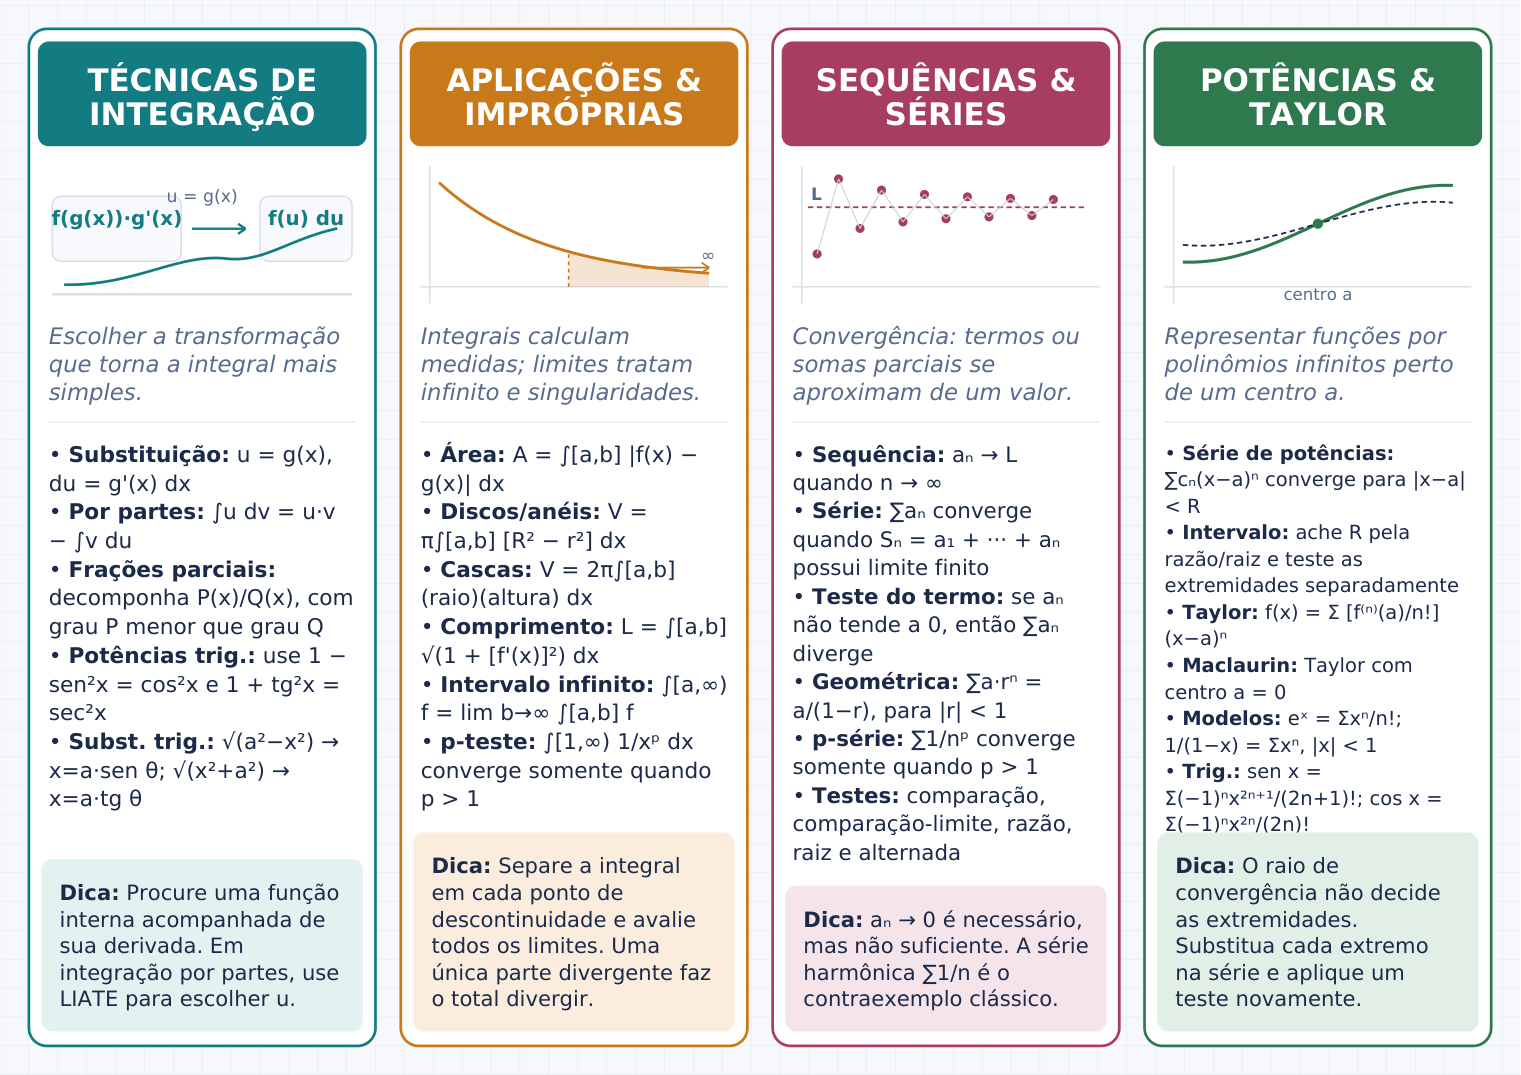

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Calculo_II.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) INTEGRACAO POR PARTES: Integral de x*e^x dx
   -> C + (x - 1)*exp(x)

2) SUBSTITUICAO TRIGONOMETRICA: Integral de 1/sqrt(9 - x^2) dx


   -> C + asin(x/3)

3) FRACOES PARCIAIS: Integral de 1/(x^2 - 1) dx
   -> C + log(x - 1)/2 - log(x + 1)/2

4) INTEGRAL IMPROPRIA: Integral de 1/x^2 de 1 a +inf
   -> 1

5) p-TESTE: convergencia da serie 1/n^p


   p = 0.5  ->  soma parcial (n=10000) = 198.5446  DIVERGE
   p = 1.0  ->  soma parcial (n=10000) = 9.7876  DIVERGE
   p = 1.5  ->  soma parcial (n=10000) = 2.5924  CONVERGE
   p = 2.0  ->  soma parcial (n=10000) = 1.6448  CONVERGE

6) SERIE GEOMETRICA: soma de (1/2)^n de 0 a +inf


   -> 2

7) MACLAURIN de e^x (6 termos)
    x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1


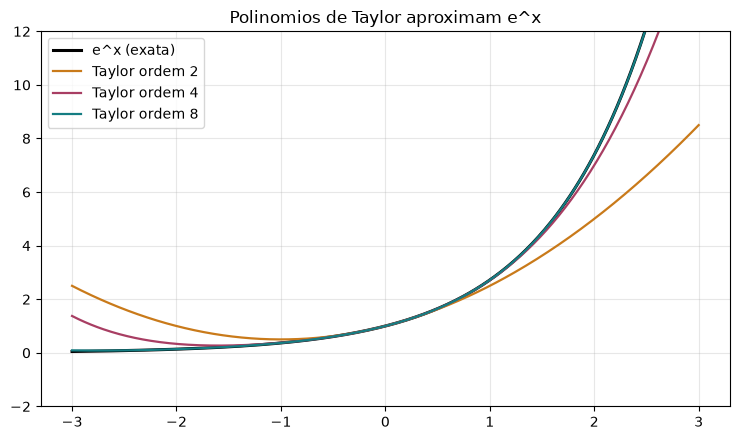


OK - series e integrais resolvidas simbolicamente.


In [3]:

%matplotlib inline
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
x, n, C = sp.symbols("x n C")

print("=" * 60)
print("1) INTEGRACAO POR PARTES: Integral de x*e^x dx")
print("   ->", sp.integrate(x * sp.exp(x), x) + C)

print("\n2) SUBSTITUICAO TRIGONOMETRICA: Integral de 1/sqrt(9 - x^2) dx")
print("   ->", sp.integrate(1/sp.sqrt(9 - x**2), x) + C)

print("\n3) FRACOES PARCIAIS: Integral de 1/(x^2 - 1) dx")
print("   ->", sp.integrate(1/(x**2 - 1), x) + C)

print("\n4) INTEGRAL IMPROPRIA: Integral de 1/x^2 de 1 a +inf")
print("   ->", sp.integrate(1/x**2, (x, 1, sp.oo)))

print("\n5) p-TESTE: convergencia da serie 1/n^p")
for p in (0.5, 1.0, 1.5, 2.0):
    s = sp.N(sp.Sum(1/n**p, (n, 1, 10000)))
    print(f"   p = {p:.1f}  ->  soma parcial (n=10000) = {float(s):.4f}  "
          f"{'CONVERGE' if p > 1 else 'DIVERGE'}")

print("\n6) SERIE GEOMETRICA: soma de (1/2)^n de 0 a +inf")
print("   ->", sp.Sum((1/2)**n, (n, 0, sp.oo)).doit())

print("\n7) MACLAURIN de e^x (6 termos)")
print("   ", sp.series(sp.exp(x), x, 0, 6).removeO())

xx = np.linspace(-3, 3, 400)
plt.figure(figsize=(7.5, 4.5))
plt.plot(xx, np.exp(xx), lw=2.2, color="k", label="e^x (exata)")
for k, col in ((2, "#C97A1A"), (4, "#A83E63"), (8, "#147D82")):
    s = sp.series(sp.exp(x), x, 0, k + 1).removeO()
    plt.plot(xx, [float(s.subs(x, i)) for i in xx], lw=1.6, color=col,
             label=f"Taylor ordem {k}")
plt.ylim(-2, 12)
plt.title("Polinomios de Taylor aproximam e^x")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("\nOK - series e integrais resolvidas simbolicamente.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
